In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

import plotly.express as px
import plotly.subplots as sp

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
print(pd.__version__)

2.3.3


In [6]:
# Load the dataset
cars_df = sns.load_dataset('mpg')

# Quick preview
print(cars_df.shape)
cars_df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [10]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [9]:
df = cars_df.copy()
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


In [ ]:
sns.set_style()

In [26]:
# Setting up plot/grid style:

# plt.style.available # This will show the plt styles which are available (the names arent intuitive, so its definitely helpful!)

sns.set_style('darkgrid')
plt.style.use('seaborn-v0_8-darkgrid')

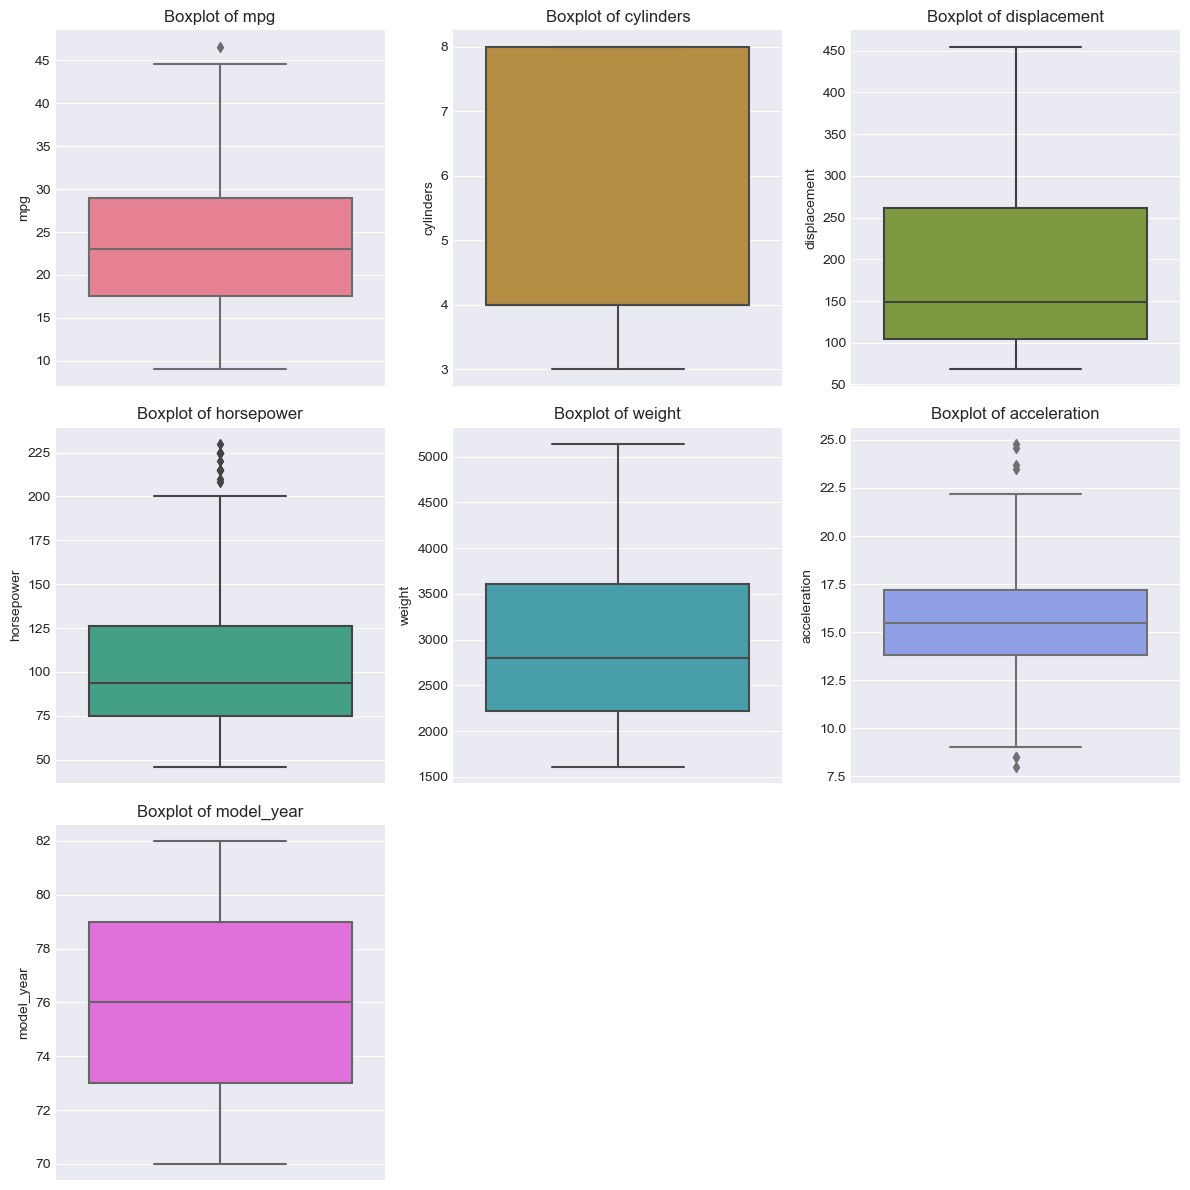

In [43]:
# NUMERIC COLS LOOP—BOXPLOT:

# Automatically select all numerical cols from a df:
numeric_cols = df.select_dtypes(include=np.number).columns

# Set the max number of plots per row:
max_cols = 3 # Adjust as needed, but keep space and visibility/readability in mind;

plt.style.use('seaborn-v0_8-darkgrid')

# Calculate the number of rows needed based on the number of numeric columns:
num_plots = len(numeric_cols)
num_rows = int(np.ceil(num_plots / max_cols) ) # Ceiling division

# Generate a list of colors; (one color per column)
colors = sns.color_palette("husl", num_plots) # Use Seaborn color palette for distinct colors;

# Create subplots with calculated rows and fixed columns:
fig, axes = plt.subplots(
    num_rows
    , max_cols
    , figsize=(max_cols * 4, num_rows * 4)
    , sharey=False # Adjust as needed; 
    )

# Flatten the axes array for easy iteration:
axes = axes.flatten()

# Loop through each numeric columns, colors and axes:
for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    sns.boxplot(
        data=df
        , y=col # can manipulate the orientation by assignment of 'x' / 'y';
        , ax=axes[i]
        , color=color
#         , orient="h"
        )
    axes[i].set_title(f'Boxplot of {col}')
    
# Hide any unused axes (if num_plots < num_rows * max_cols):
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
    
# Adjust layout and display the plot(s):
plt.style.use('seaborn-v0_8-darkgrid')
plt.tight_layout()
plt.show();

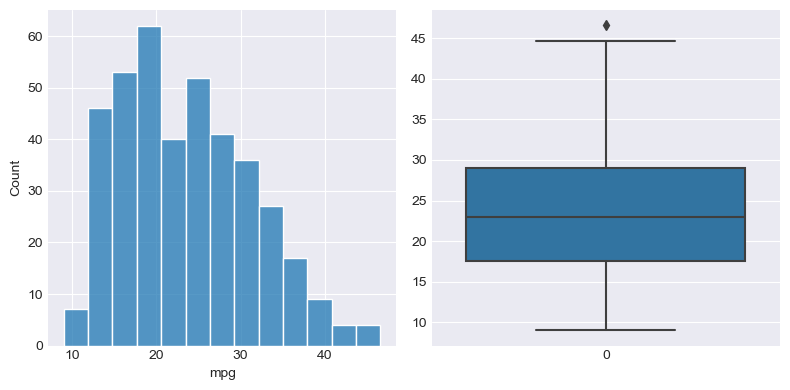

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.histplot(df['mpg'], ax=ax[0])
sns.boxplot(df['mpg'], ax=ax[1])

plt.tight_layout()
plt.show();

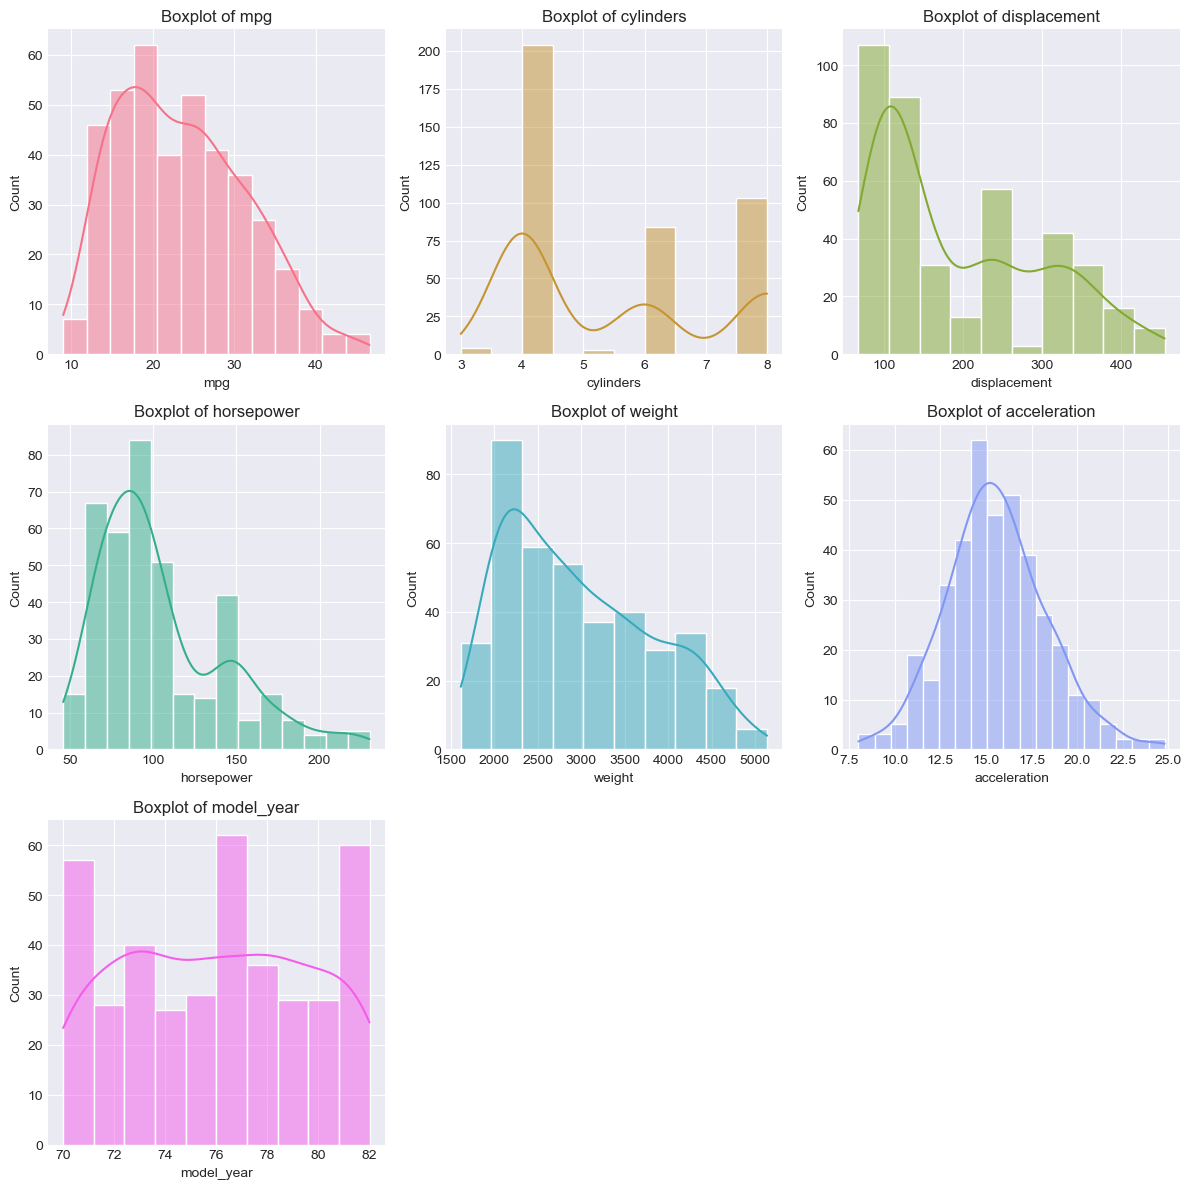

In [45]:
# NUMERIC COLS LOOP—HISTPLOT:

# Automatically select all numerical cols from a df:
numeric_cols = df.select_dtypes(include=np.number).columns

# Set the max number of plots per row:
max_cols = 3 # Adjust as needed, but keep space and visibility/readability in mind;

# Calculate the number of rows needed based on the number of numeric columns:
num_plots = len(numeric_cols)
num_rows = int(np.ceil(num_plots / max_cols) ) # Ceiling division

# Generate a list of colors; (one color per column)
colors = sns.color_palette("husl", num_plots) # Use Seaborn color palette for distinct colors;

# Create subplots with calculated rows and fixed columns:
fig, axes = plt.subplots(
    num_rows
    , max_cols
    , figsize=(max_cols * 4, num_rows * 4)
    , sharey=False # Adjust as needed; 
    )

# Flatten the axes array for easy iteration:
axes = axes.flatten()

# Loop through each numeric columns, colors and axes:
for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    sns.histplot(
        df[col]
        , kde=True
        , ax=axes[i]
        , color=color
        )
    
    axes[i].set_title(f'Boxplot of {col}')
#     axes[i].grid() # remove; not actually showing grid!
#     plt.style.use('seaborn-v0_8-darkgrid') # Can set preferred style in the loop or outside (added @ end;)
    
# Hide any unused axes (if num_plots < num_rows * max_cols):
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
    
# Adjust layout and display the plot(s):
plt.style.use('seaborn-v0_8-darkgrid')
plt.tight_layout()
plt.show();

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_cols(
    df: pd.DataFrame
    , plot_type: str = "boxplot"
    , max_cols: int = 3
    , figsize: tuple = (12, 8)
    , sharey: bool = False
    , palette: str = "husl"
    , orient: str = "v"
):
    """
    Plot all numeric columns in a DataFrame as boxplots or histplots.

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the data to plot.
    plot_type : str, optional (default="boxplot")
        Type of plot: "boxplot" or "histplot".
    max_cols : int, optional (default=3)
        Maximum number of plots per row.
    figsize : tuple, optional (default=(12, 8))
        Figure size (width, height) in inches.
    sharey : bool, optional (default=False)
        If True, y-axes will be shared across all subplots.
    palette : str, optional (default="husl")
        Seaborn color palette to use.
    orient : str, optional (default="v")
        Orientation of the plot: "v" (vertical) or "h" (horizontal).
    """
    # Select only numeric columns
    numeric_cols = df.select_dtypes(include=np.number).columns
    num_plots = len(numeric_cols)

    # Calculate number of rows needed
    num_rows = int(np.ceil(num_plots / max_cols))

    # Generate colors
    colors = sns.color_palette(palette, num_plots)

    # Create subplots
    fig, axes = plt.subplots(
        num_rows, max_cols, figsize=figsize, sharey=sharey
    )
    axes = axes.flatten()

    # Plot each numeric column
    for i, (col, color) in enumerate(zip(numeric_cols, colors)):
        if plot_type == "boxplot":
            sns.boxplot(data=df, y=col, ax=axes[i], color=color, orient=orient)
            axes[i].set_title(f"Boxplot of {col}")
        elif plot_type == "histplot":
            sns.histplot(data=df, x=col, ax=axes[i], color=color, kde=True)
            axes[i].set_title(f"Histogram of {col}")
        else:
            raise ValueError("plot_type must be 'boxplot' or 'histplot'")

    # Hide unused axes
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and display
    plt.style.use("seaborn-v0_8-darkgrid")
    plt.tight_layout()
    plt.show();

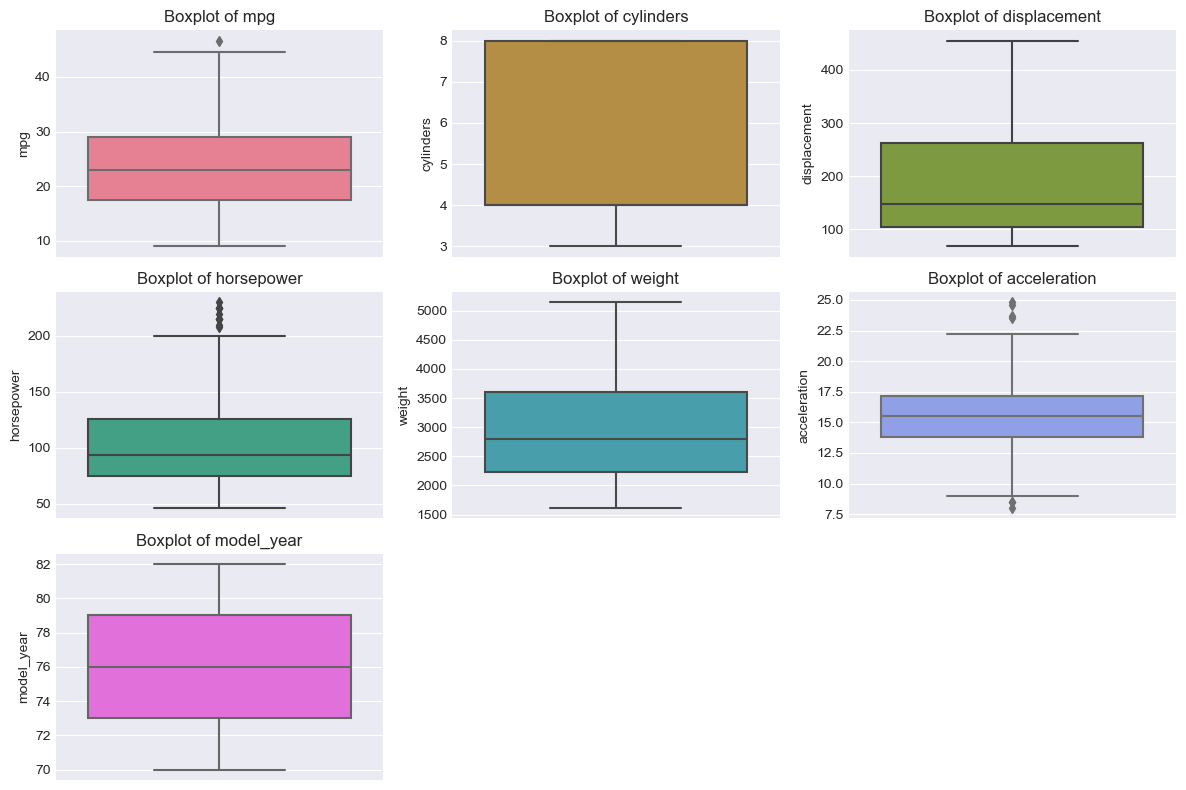

In [51]:
# Example usage:
plot_numeric_cols(df, plot_type="boxplot", max_cols=3)

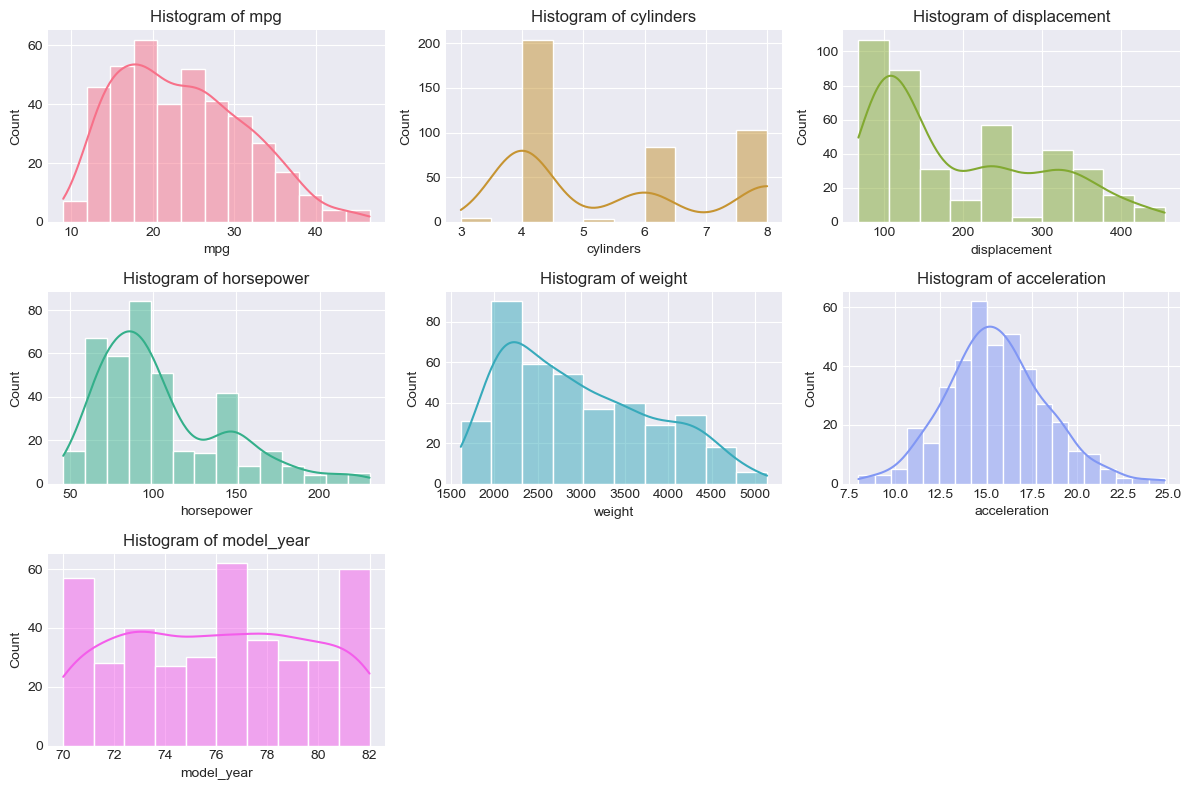

In [52]:
# Example usage:
plot_numeric_cols(df, plot_type="histplot", max_cols=3)

/Users/t4ng0_br4v0/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



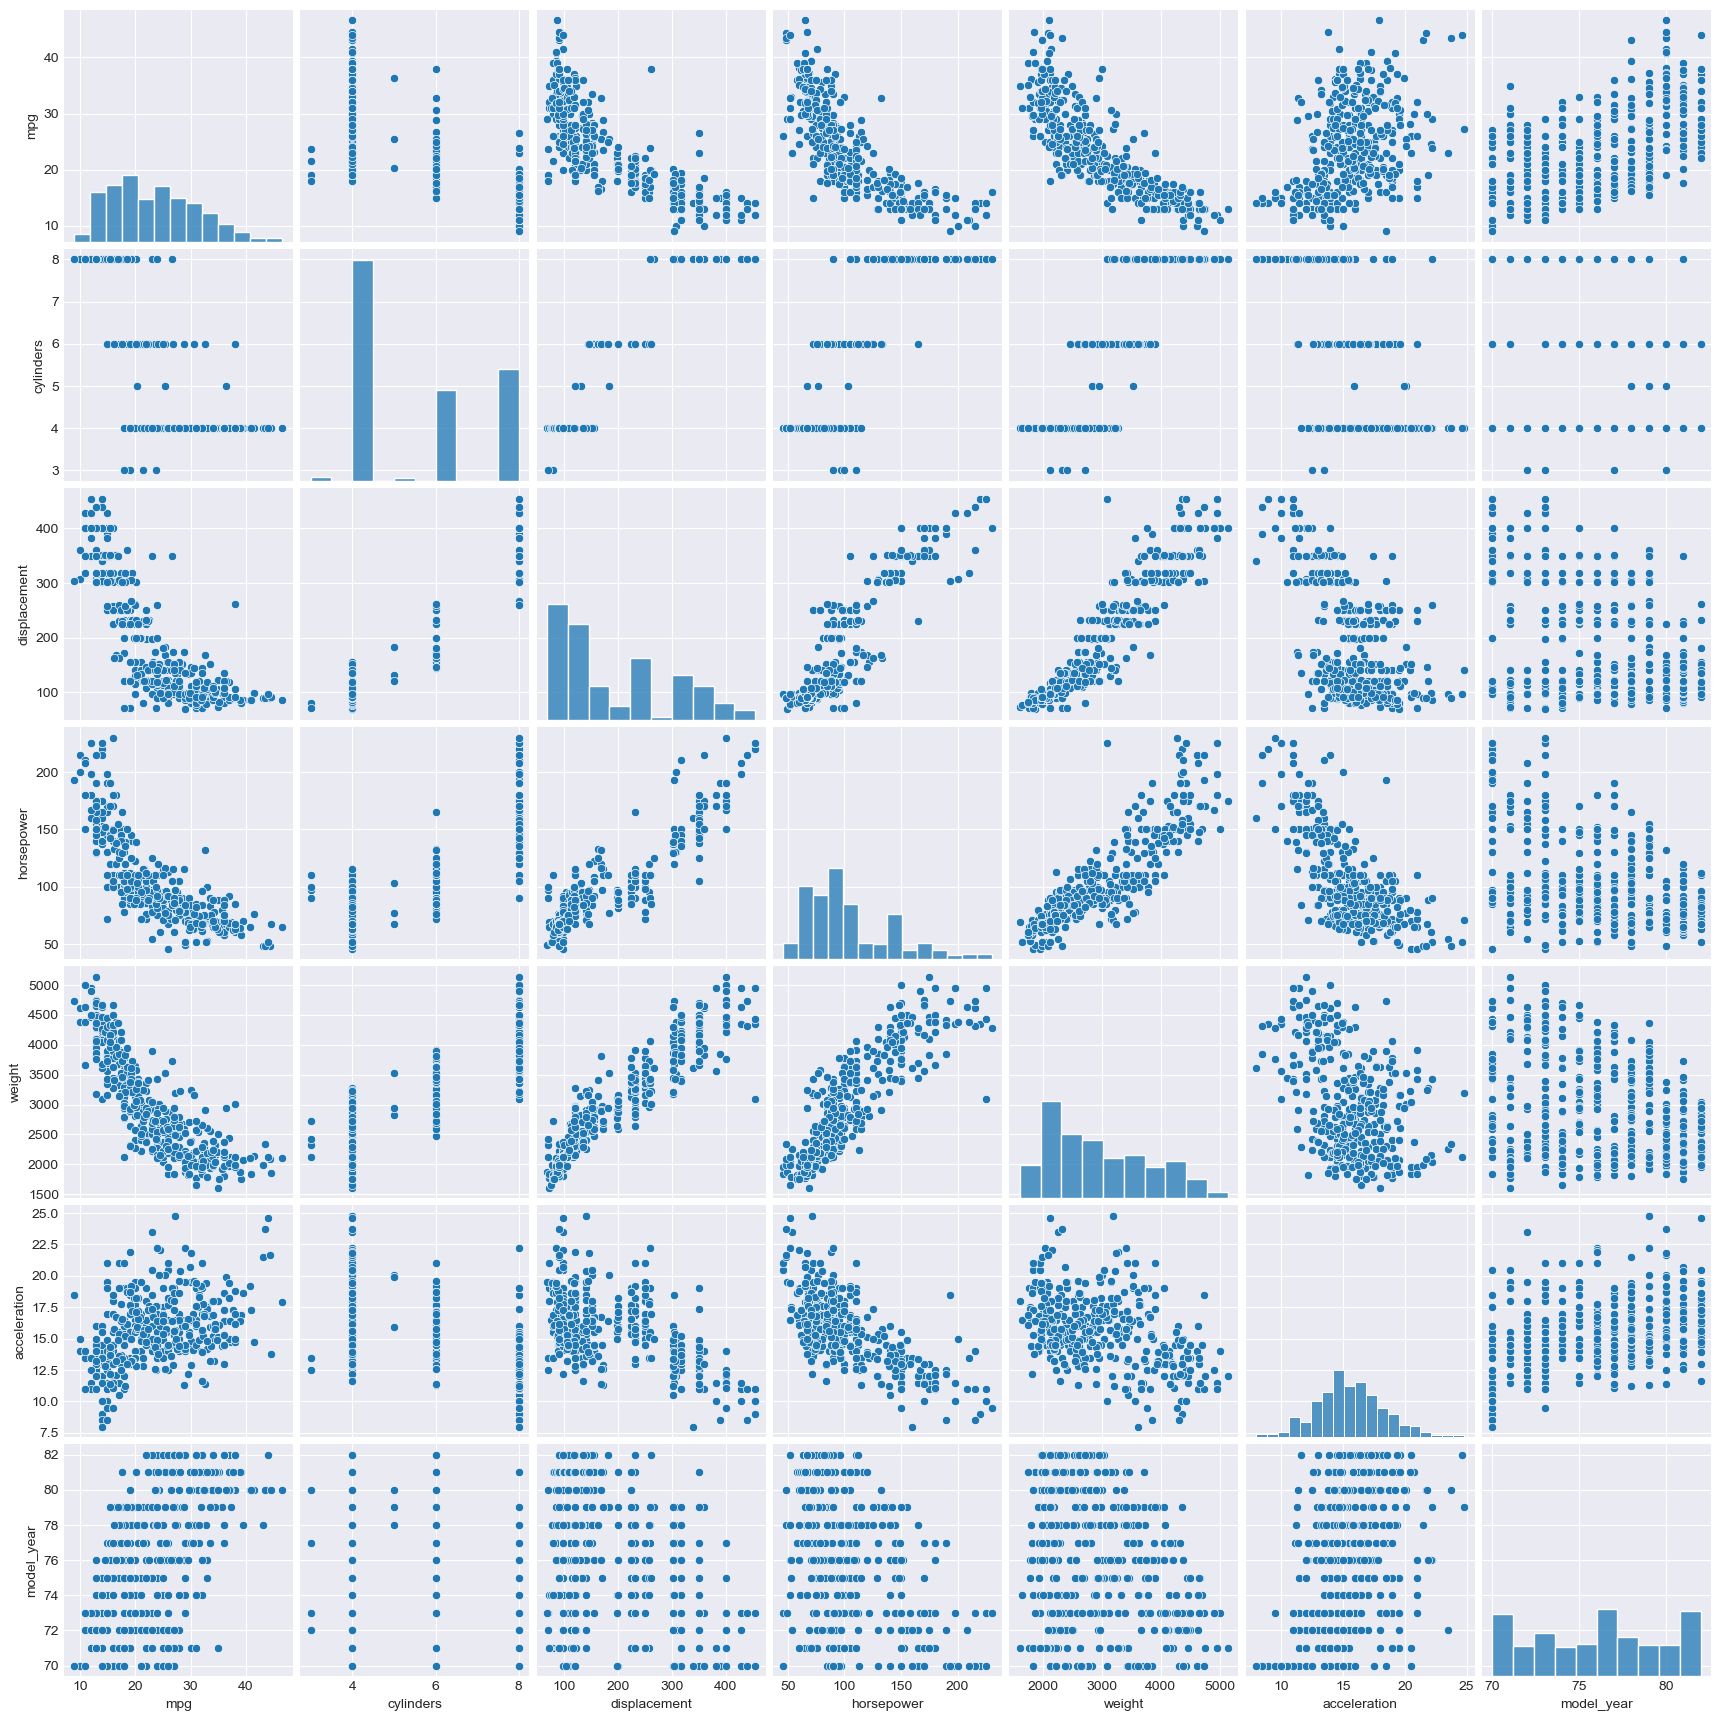

In [53]:
sns.pairplot(data=df[df[]] )

In [ ]:
'''
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load example data
iris = sns.load_dataset('iris')

# Method A: Use .drop() to create a new DataFrame without the column
# We exclude the 'species' column, for example
cols_to_plot = iris.drop(columns=['species']) 
sns.pairplot(cols_to_plot)
plt.show()

# Method B: Use boolean indexing with .loc for a view
# Select all columns except 'species'
cols_to_plot_loc = iris.loc[:, iris.columns != 'species']
sns.pairplot(cols_to_plot_loc)
plt.show()

'''

/Users/t4ng0_br4v0/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight

/var/folders/1f/qp8ybngx08xb4wxl63p814r80000gn/T/ipykernel_31752/1499170699.py:5: UserWarning:

The figure layout has changed to tight



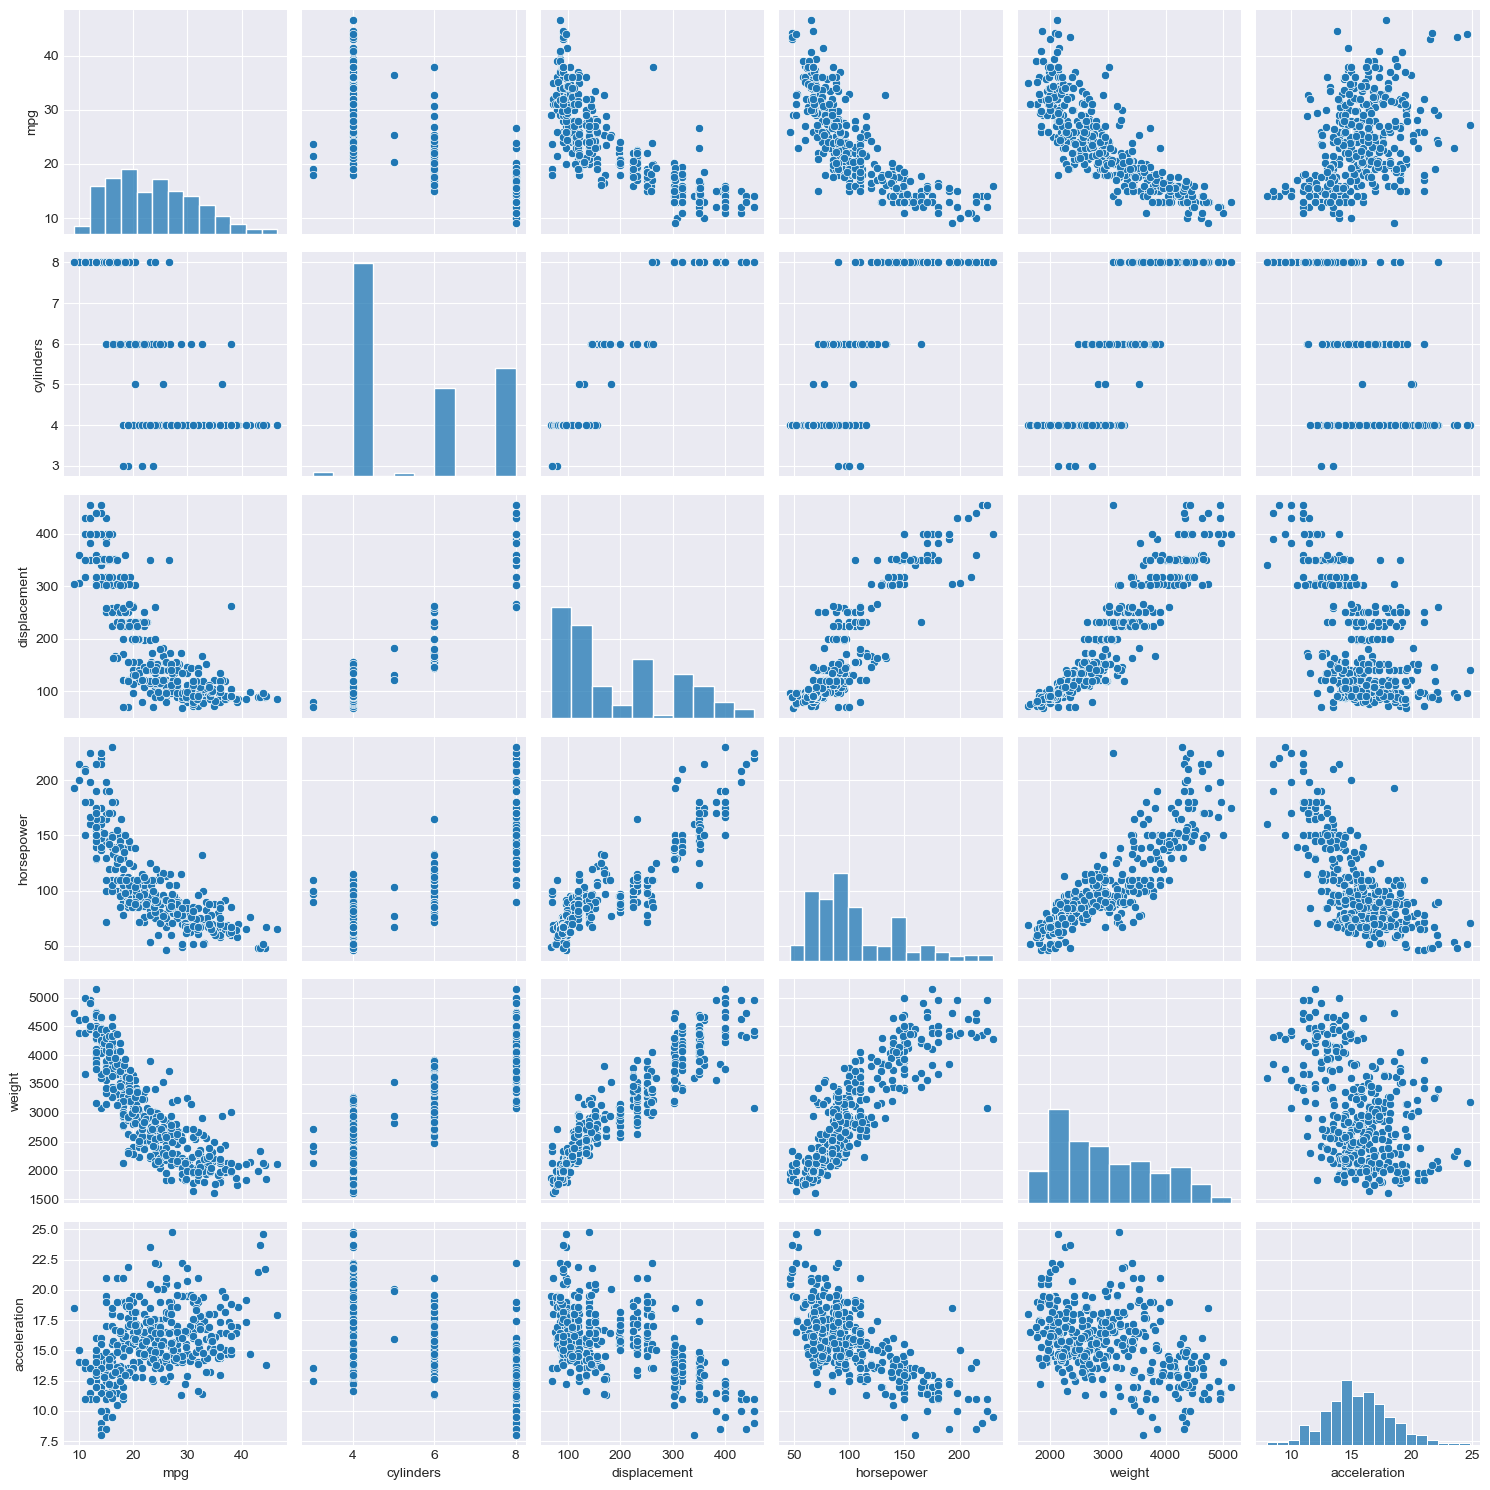

In [59]:
# cols_to_plot = df.drop(columns=['model_year'])
# sns.pairplot(data=cols_to_plot)

sns.pairplot(data=df.drop(columns=['model_year']))
plt.tight_layout()
plt.show();